In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

import numpy as np
import matplotlib.pyplot as plt

In [20]:
dataset_path = "Dataset"

In [21]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [22]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 22048 images belonging to 2 classes.


In [23]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 5510 images belonging to 2 classes.


In [24]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPool2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 22048 images belonging to 2 classes.


In [28]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.9564 - loss: 0.1420 - val_accuracy: 0.9452 - val_loss: 0.1581
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 47s 68ms/step - accuracy: 0.9573 - loss: 0.1373 - val_accuracy: 0.9425 - val_loss: 0.1685
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.9566 - loss: 0.1366 - val_accuracy: 0.9470 - val_loss: 0.1551
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9568 - loss: 0.1379 - val_accuracy: 0.9446 - val_loss: 0.1525
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.9570 - loss: 0.1365 - val_accuracy: 0.9465 - val_loss: 0.1609
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.9589 - loss: 0.1316 - val_accuracy: 0.9430 - val_loss: 0.1618
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9559 - loss: 0.1353 - val_accuracy: 0.9461 - val_loss: 0.1557
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9571 - loss: 0.1310 - 

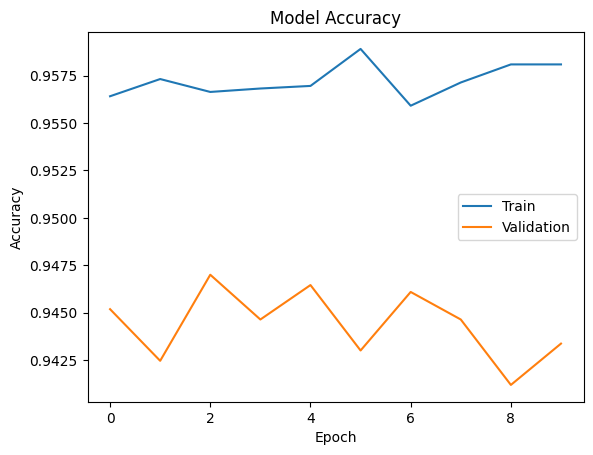

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [30]:
model.save("malaria_detection_model.h5")